In [2]:
import sys
import json
import types
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader
from lightning.pytorch import Trainer
import matplotlib.pyplot as plt

# Paths
BASE        = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR = BASE / "data/processed/patches"
STATS_PATH  = PATCHES_DIR / "stats.json"
PRETRAINED  = BASE / "data/pretrained"
CKPT_DIR    = BASE / "checkpoints/phase2.1"

sys.path.insert(0, str(BASE))

from scripts.utils.dataset import SRDataset
from scripts.training.train import build_model, get_model_class, load_config

# Load statistics
with open(STATS_PATH) as f:
    stats = json.load(f)

HR_MEAN    = stats["hr"]["mean"]
HR_STD     = stats["hr"]["std"]
LR_MEAN    = stats["lr"]["mean"]
LR_STD     = stats["lr"]["std"]
DATA_RANGE = stats["hr_data_range"]
DATA_MIN   = stats["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAMES = ["edsr", "swinir", "hat", "realesrgan"]

# Dataset and DataLoader
test_ds = SRDataset(
    split="test",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    repeat_channels=True,
    transform=None,
    use_water_mask=True,
)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=4)
args = types.SimpleNamespace(lr=1e-4)


Device: cuda


In [3]:
# same tiles used across all plots
np.random.seed(0)
N_SAMPLES = 1
indices   = np.random.choice(len(test_ds), N_SAMPLES, replace=False)
samples   = [test_ds[i] for i in indices]
print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['HAUT_2025_b0_r1280_c3840.npy']


In [3]:
def prep_sample(sample):
    hr_mask = sample["hr_mask"].squeeze().numpy()
    lr_64   = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256  = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    lr_np   = np.where(hr_mask > 0.5, lr_256, np.nan)
    hr_np   = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np   = np.where(hr_mask > 0.5, hr_np, np.nan)

    valid = hr_np[hr_mask > 0.5]

    vmin = np.nanpercentile(valid, 1)
    vmax = np.nanpercentile(valid, 99)

    return lr_np, hr_np, hr_mask, vmin, vmax

### Zero-shot inference

In [4]:
zeroshot_results = {}
loaded_pt_models = {}

for model_name in MODEL_NAMES:
    print(f"\n[INFO] Evaluating Zero-Shot: {model_name.upper()}...")
    cfg = load_config(model_name)
    model_pt = build_model(model_name, cfg, stats, args)
    
    # Store for plotting later
    loaded_pt_models[model_name] = model_pt

    trainer = Trainer(
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        precision=cfg.get("precision", "bf16-mixed"),
        logger=False,
        enable_checkpointing=False,
    )
    
    metrics = trainer.test(model_pt, dataloaders=test_loader, ckpt_path=None, verbose=False)
    zeroshot_results[model_name] = metrics[0]

df_zeroshot = pd.DataFrame(zeroshot_results).T
print("\n--- Zero-Shot Test Set Performance ---")
display(df_zeroshot)


[INFO] Evaluating Zero-Shot: EDSR...


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /share/home/e2406751/.conda/envs/sisr/lib/python3.11 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[DEBUG] pretrained_path: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[DEBUG] ae_path: None
[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers


Output()

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: 
FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the 
default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary 
code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more 
details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the 
functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via 
this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We 
recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded 
file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)

...


[INFO] Evaluating Zero-Shot: REALESRGAN...
[DEBUG] pretrained_path: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[DEBUG] ae_path: None
[INFO] Generator loaded
[INFO] Discriminator loaded


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Ligh

Output()


--- Zero-Shot Test Set Performance ---


,test/land_psnr,test/land_ssim,test/land_mae,test/land_rmse,test/land_lpips,test/water_psnr,test/water_ssim,test/water_mae,test/water_rmse,test/water_lpips
edsr,13.909495,0.215067,4.614736,5.774065,0.730048,10.577632,0.195705,7.974877,8.316073,0.714653
swinir,15.075895,0.416728,4.043028,5.032425,0.646050,14.806671,0.374292,4.248136,5.303852,0.635417
hat,15.420161,0.518893,3.894692,4.834158,0.642144,15.240324,0.477603,4.120126,5.092611,0.635417
realesrgan,15.707768,0.384871,3.793466,4.744319,0.594184,12.526538,0.374909,6.265018,6.753282,0.603082


In [17]:
@torch.no_grad()
def get_sr_pt(model_name, sample):
    """Zero-shot prediction from memory using model_name string."""
    # Handles either dict name you used (loaded_models or loaded_pt_models)
    model = loaded_models[model_name] if "loaded_models" in globals() else loaded_pt_models[model_name]
    model.eval().to(device)
    lr = sample["lr"].unsqueeze(0).to(device)
    sr = model(lr)
    return (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()


In [6]:
TARGET_TILES = ["HAUT_2025_b0_r4608_c1536.npy"]

samples = []
for idx in range(len(test_ds)):
    # Check if target name matches (handles with or without .npy extension)
    current_fname = str(test_ds[idx]["fname"])
    if any(target in current_fname for target in TARGET_TILES):
        samples.append(test_ds[idx])

if not samples:
    raise ValueError(f"None of the target tiles {TARGET_TILES} were found in test_ds!")

print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['HAUT_2025_b0_r4608_c1536.npy']


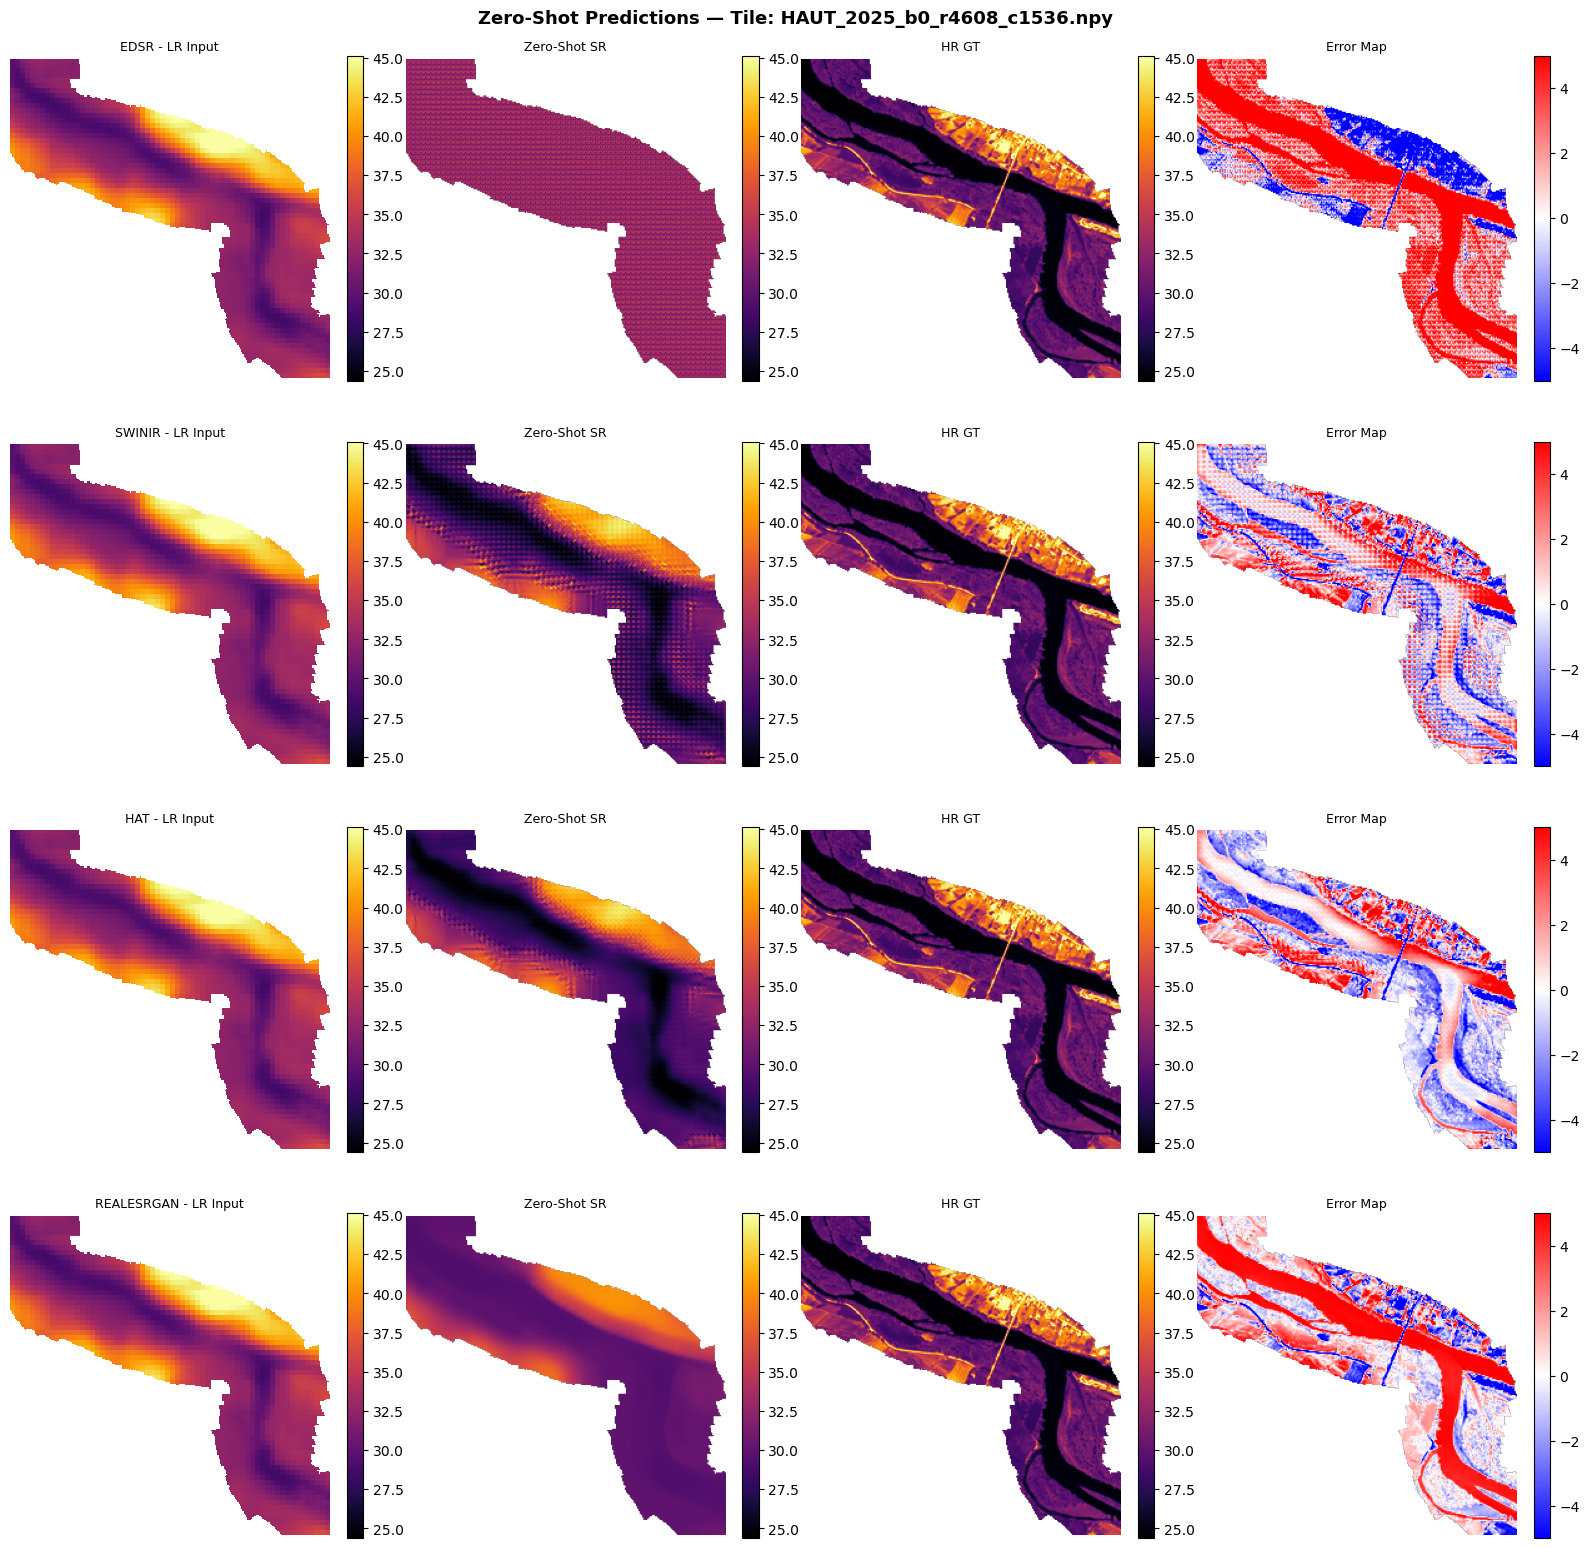

In [ ]:
for sample in samples:
    fname   = sample["fname"]
    hr_mask = sample["hr_mask"].squeeze().numpy()
    
    # Physical Temperature Conversion (°C)
    lr_64  = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1) # Upsample for alignment
    lr_np  = np.where(hr_mask > 0.5, lr_256, np.nan)
    
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np  = np.where(hr_mask > 0.5, hr_np, np.nan)

    # Colorbar range from 1st to 99th percentile of valid pixels
    valid = hr_np[hr_mask > 0.5]
    vmin, vmax = np.nanpercentile(valid, 1), np.nanpercentile(valid, 99)

    fig, axes = plt.subplots(len(MODEL_NAMES), 4, figsize=(16, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"Zero-Shot Predictions — Tile: {fname}", fontsize=13, fontweight="bold")

    for m_idx, model_name in enumerate(MODEL_NAMES):
        model_zi = loaded_pt_models[model_name]
        
        # Inference & Residual computation
        sr_np    = get_sr_pt(model_zi, sample)
        sr_np    = np.where(hr_mask > 0.5, sr_np, np.nan)
        residual = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

        # 1. LR Input
        im0 = axes[m_idx, 0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax, interpolation="nearest")
        axes[m_idx, 0].set_title(f"{model_name.upper()} - LR Input", fontsize=9)
        axes[m_idx, 0].axis("off")
        plt.colorbar(im0, ax=axes[m_idx, 0], fraction=0.046)

        # 2. SR Zero-Shot Output
        im1 = axes[m_idx, 1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"Zero-Shot SR", fontsize=9)
        axes[m_idx, 1].axis("off")
        plt.colorbar(im1, ax=axes[m_idx, 1], fraction=0.046)

        # 3. Ground Truth HR
        im2 = axes[m_idx, 2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title("HR GT", fontsize=9)
        axes[m_idx, 2].axis("off")
        plt.colorbar(im2, ax=axes[m_idx, 2], fraction=0.046)

        # 4. Residual Error Map
        im3 = axes[m_idx, 3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
        axes[m_idx, 3].set_title("Error Map", fontsize=9)
        axes[m_idx, 3].axis("off")
        plt.colorbar(im3, ax=axes[m_idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.show()

### Fine-tune

In [13]:
# Checkpoints and model names
CKPT_DIR = BASE / "checkpoints/phase2.1"

CHECKPOINTS = {
    "edsr":       CKPT_DIR / "edsr/edsr_phase2_epoch=59_val/water_mae=1.5755.ckpt",
    "swinir":     CKPT_DIR / "swinir/swinir_phase2_epoch=45_val/water_mae=1.2733.ckpt",
    "hat":        CKPT_DIR / "hat/hat_phase2_epoch=41_val/water_mae=1.3762.ckpt",
    "realesrgan": CKPT_DIR / "realesrgan/realesrgan_phase2_epoch=17_val/water_mae=1.5400.ckpt",
}

In [14]:
loaded_ft_models = {}

common_kwargs = dict(
    hr_mean=HR_MEAN, hr_std=HR_STD,
    data_range=DATA_RANGE, data_min=DATA_MIN, phase=2
)

# Load fine-tuned models directly into memory (no testing loop)
for model_name in MODEL_NAMES:
    ckpt_path = CHECKPOINTS.get(model_name)
    
    if ckpt_path and ckpt_path.exists():
        print(f"[INFO] Loading FT {model_name.upper()} from: {ckpt_path.name}")
        cls = get_model_class(model_name)
        
        model_ft = cls.load_from_checkpoint(str(ckpt_path), strict=False, **common_kwargs)
        loaded_ft_models[model_name] = model_ft
    else:
        print(f"Warning: Checkpoint path not found for {model_name.upper()}: {ckpt_path}")

[INFO] Loading FT EDSR from: water_mae=1.5755.ckpt


[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers
[INFO] Loading FT SWINIR from: water_mae=1.2733.ckpt
[INFO] Loading SwinIR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 550/550 layers
[INFO] Loading FT HAT from: water_mae=1.3762.ckpt
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
[INFO] Loading FT REALESRGAN from: water_mae=1.5400.ckpt
[INFO] Generator loaded
[INFO] Discriminator loaded


In [12]:
TARGET_TILES = ["HAUT_2025_b0_r4608_c1536.npy"]

samples = []
for idx in range(len(test_ds)):
    # Check if target name matches (handles with or without .npy extension)
    current_fname = str(test_ds[idx]["fname"])
    if any(target in current_fname for target in TARGET_TILES):
        samples.append(test_ds[idx])

if not samples:
    raise ValueError(f"None of the target tiles {TARGET_TILES} were found in test_ds!")

print(f"Selected tiles: {[s['fname'] for s in samples]}")

Selected tiles: ['HAUT_2025_b0_r4608_c1536.npy']


In [18]:
@torch.no_grad()
def get_sr_ft(model_name, sample):
    """Fine-tuned prediction from memory using model_name string."""
    model = loaded_ft_models[model_name]
    model.eval().to(device)
    lr = sample["lr"].unsqueeze(0).to(device)
    sr = model(lr)
    return (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


[INFO] Loading EDSR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68/74 layers


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['lpips_fn.net.net.slice1.0.weight', 'lpips_fn.net.net.slice1.0.bias', 'lpips_fn.net.net.slice1.2.weight', 'lpips_fn.net.net.slice1.2.bias', 'lpips_fn.net.net.slice2.5.weight', 'lpips_fn.net.net.slice2.5.bias', 'lpips_fn.net.net.slice2.7.weight', 'lpips_fn.net.net.slice2.7.bias', 'lpips_fn.net.net.slice3.10.weight', 'lpips_fn.net.net.slice3.10.bias', 'lpips_fn.net.net.slice3.12.weight', 'lpips_fn.net.net.slice3.12.bias', 'lpips_fn.net.net.slice3.14.weight', 'lpips_fn.net.net.slice3.14.bias', 'lpips_fn.net.net.slice4.17.weight', 'lpips_fn.net.net.slice4.17.bias', 'lpips_fn.net.net.slice4.19.weight', 'lpips_fn.net.net.slice4.19.bias', 'lpips_fn.net.net.slice4.21.weight', 'lpips_fn.net.net.slice4.21.bias', 'lpips_fn.net.net.slice5.24.weight', 'lpips_fn.net.net.slice5.24.bias', 'lpips_fn.net.net.slice5.26.weight', 'l

[INFO] Loading SwinIR pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 550/550 layers
[INFO] Fetching HAT arch from GitHub...
[INFO] Loading HAT pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 864/864 layers
[INFO] Generator loaded
[INFO] Discriminator loaded


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


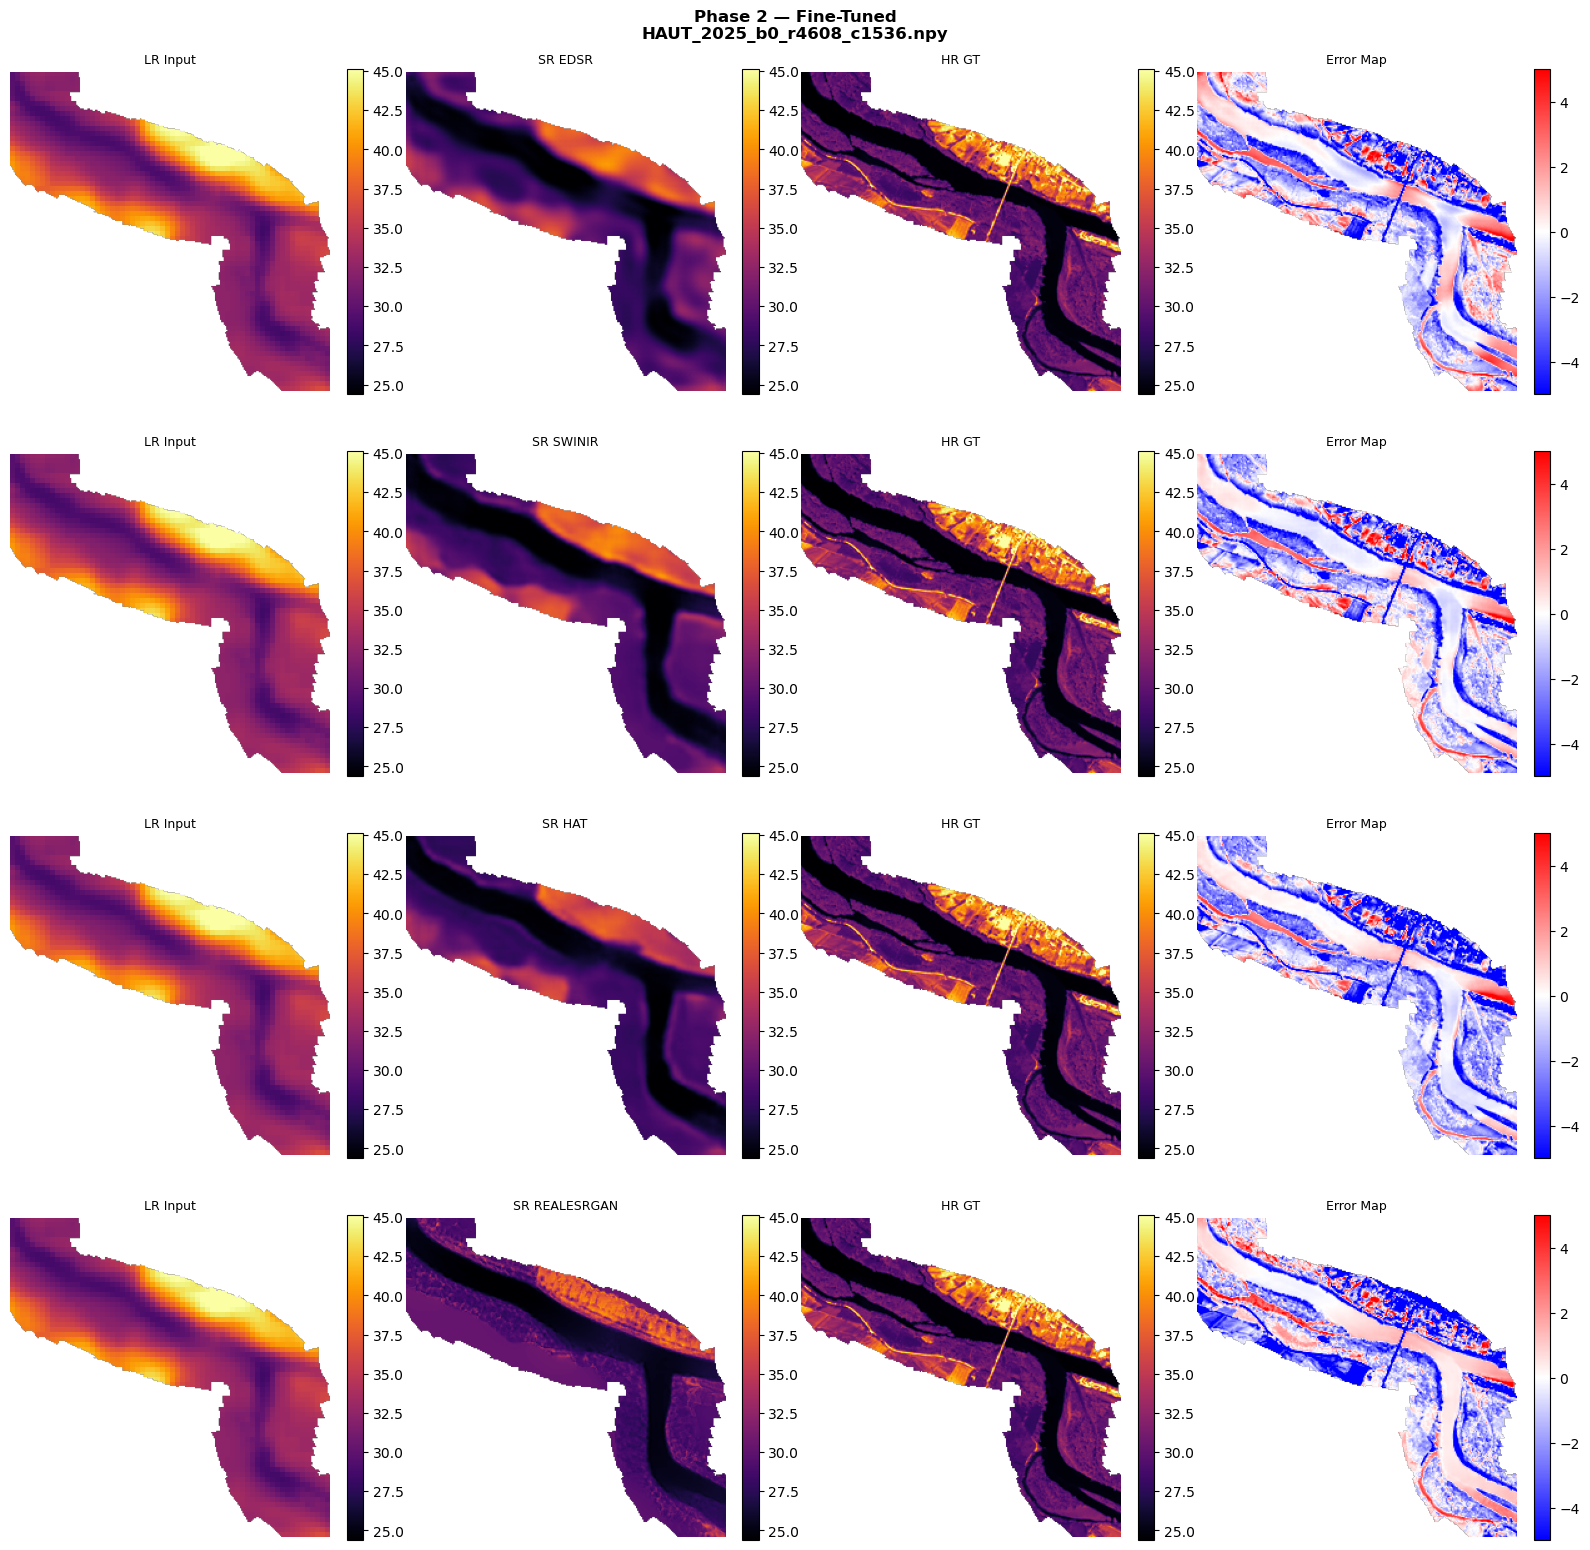

In [8]:
# Plot Phase 2 fine-tuned
# Columns: LR | SR | HR | Residual
for s_idx, sample in enumerate(samples):
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    fig, axes = plt.subplots(len(MODEL_NAMES), 4,
                             figsize=(16, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"Phase 2 — Fine-Tuned\n{fname}",
                 fontsize=12, fontweight="bold")

    for m_idx, model_name in enumerate(MODEL_NAMES):
        sr_np    = get_sr_ft(model_name, sample)
        sr_np    = np.where(hr_mask > 0.5, sr_np, np.nan)
        residual = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)
        res_lim  = min(np.nanmax(np.abs(residual[hr_mask > 0.5])), 10) \
                   if np.isfinite(residual).any() else 5

        im = axes[m_idx, 0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 0].set_title("LR Input", fontsize=9)
        axes[m_idx, 0].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 0], fraction=0.046)

        im = axes[m_idx, 1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"SR {model_name.upper()}", fontsize=9)
        axes[m_idx, 1].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 1], fraction=0.046)

        im = axes[m_idx, 2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title("HR GT", fontsize=9)
        axes[m_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 2], fraction=0.046)

        im = axes[m_idx, 3].imshow(residual, cmap="bwr",
                                   vmin=-5, vmax=5)
        axes[m_idx, 3].set_title(f"Error Map", fontsize=9)
        axes[m_idx, 3].axis("off")
        plt.colorbar(im, ax=axes[m_idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.show()

### Difference maps

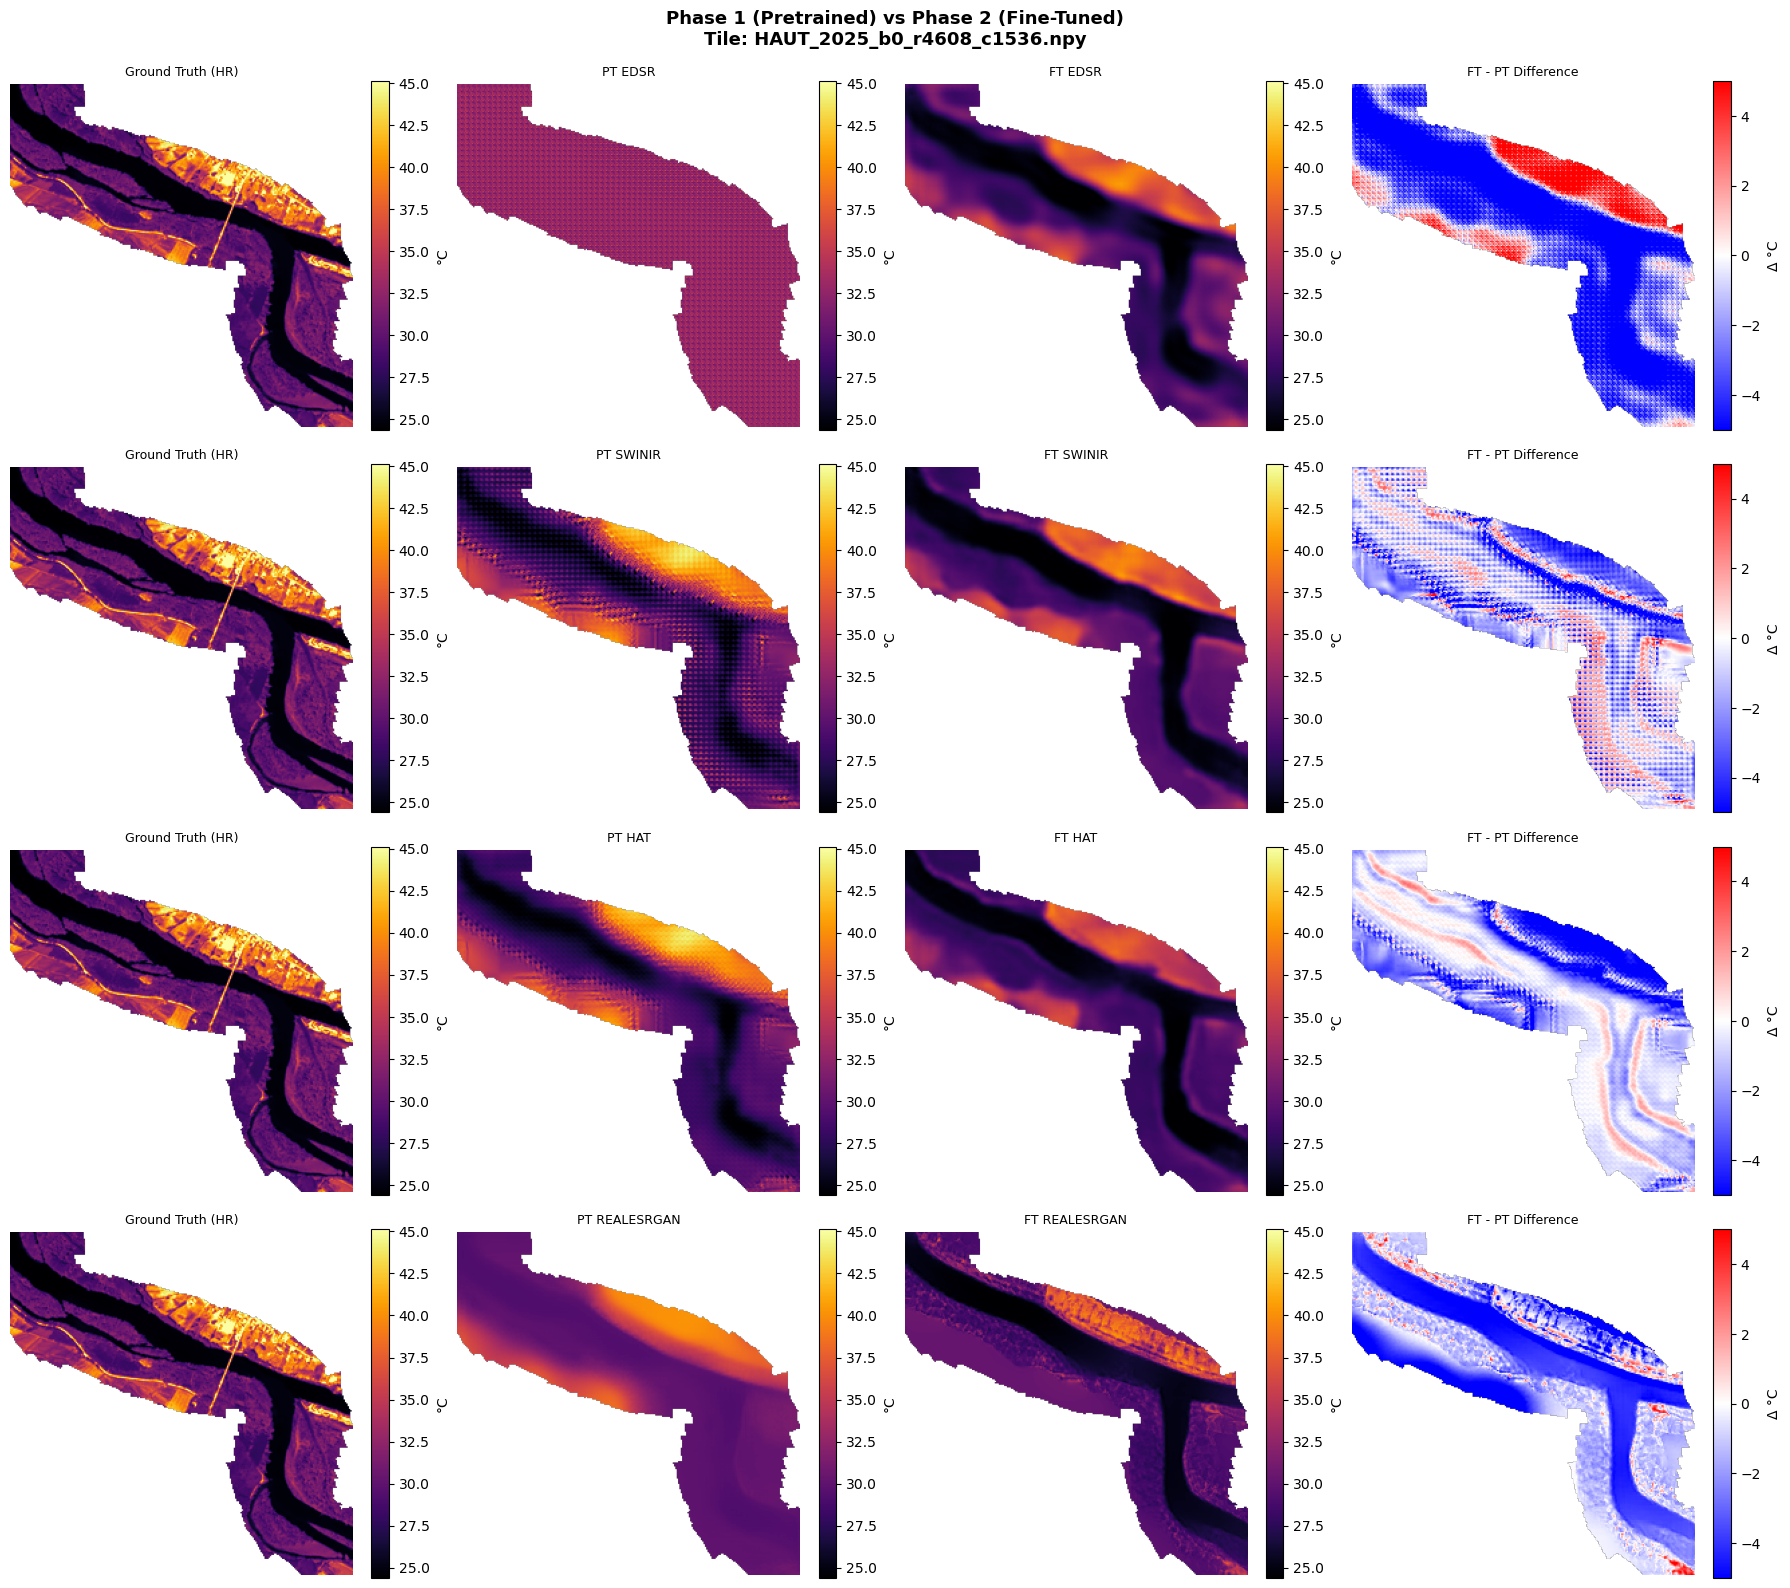

In [19]:
for sample in samples:
    fname   = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    fig, axes = plt.subplots(len(MODEL_NAMES), 4, figsize=(18, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"Phase 1 (Pretrained) vs Phase 2 (Fine-Tuned)\nTile: {fname}", 
                 fontsize=13, fontweight="bold", y=0.99)

    for m_idx, model_name in enumerate(MODEL_NAMES):
        # 1. Zero-shot prediction (PT)
        sr_pt = get_sr_pt(model_name, sample)
        sr_pt = np.where(hr_mask > 0.5, sr_pt, np.nan)

        # 2. Fine-tuned prediction (FT)
        sr_ft = get_sr_ft(model_name, sample)
        sr_ft = np.where(hr_mask > 0.5, sr_ft, np.nan)

        # 3. Difference map (FT - PT)
        diff = np.where(hr_mask > 0.5, sr_ft - sr_pt, np.nan)
        diff_lim = min(np.nanmax(np.abs(diff[hr_mask > 0.5])), 5.0) if np.isfinite(diff).any() else 2.0

        # Col 0 — Ground Truth HR
        im0 = axes[m_idx, 0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 0].set_title("Ground Truth (HR)", fontsize=9)
        axes[m_idx, 0].axis("off")
        plt.colorbar(im0, ax=axes[m_idx, 0], fraction=0.046, label="°C")

        # Col 1 — Pretrained SR
        im1 = axes[m_idx, 1].imshow(sr_pt, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 1].set_title(f"PT {model_name.upper()}", fontsize=9)
        axes[m_idx, 1].axis("off")
        plt.colorbar(im1, ax=axes[m_idx, 1], fraction=0.046, label="°C")

        # Col 2 — Fine-Tuned SR
        im2 = axes[m_idx, 2].imshow(sr_ft, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[m_idx, 2].set_title(f"FT {model_name.upper()}", fontsize=9)
        axes[m_idx, 2].axis("off")
        plt.colorbar(im2, ax=axes[m_idx, 2], fraction=0.046, label="°C")

        # Col 3 — Difference Map (FT - PT)
        im3 = axes[m_idx, 3].imshow(diff, cmap="bwr", vmin=-diff_lim, vmax=diff_lim)
        axes[m_idx, 3].set_title("FT - PT Difference", fontsize=9)
        axes[m_idx, 3].axis("off")
        plt.colorbar(im3, ax=axes[m_idx, 3], fraction=0.046, label="Δ °C")

    plt.tight_layout()
    plt.show()